In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = pd.DataFrame({
    "Date": pd.date_range(start="2025-01-01", periods=15),
    "Stock_A": [100, 102, 101, 105, 108, 107, 111, 114, 113, 117, 120, 118, 122, 125, 128],
    "Stock_B": [80, 81, 83, 82, 84, 86, 85, 88, 90, 89, 91, 93, 92, 95, 97],
    "Stock_C": [150, 148, 151, 149, 153, 156, 154, 158, 161, 159, 163, 166, 164, 168, 171],
    "Market_Index": [1000, 1010, 1005, 1020, 1035, 1030, 1045, 1060, 1055, 1075, 1090, 1080, 1100, 1115, 1130]
})

prices = prices.set_index("Date")

print(prices.head())


            Stock_A  Stock_B  Stock_C  Market_Index
Date                                               
2025-01-01      100       80      150          1000
2025-01-02      102       81      148          1010
2025-01-03      101       83      151          1005
2025-01-04      105       82      149          1020
2025-01-05      108       84      153          1035


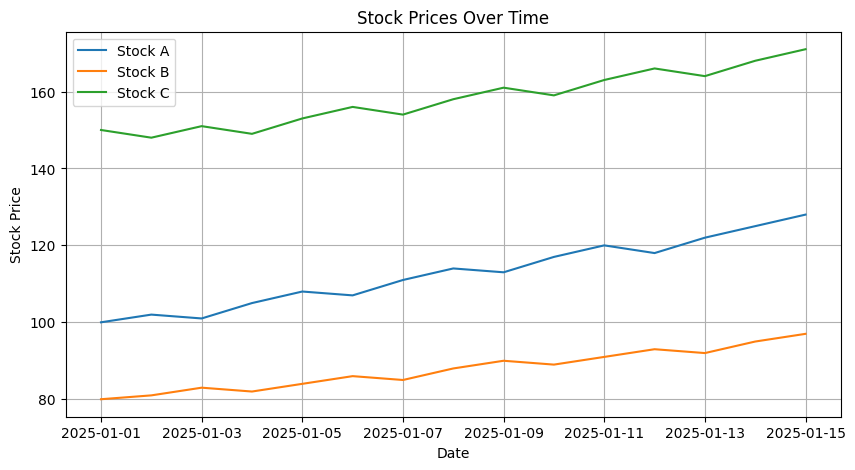

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(prices.index, prices["Stock_A"], label="Stock A")
plt.plot(prices.index, prices["Stock_B"], label="Stock B")
plt.plot(prices.index, prices["Stock_C"], label="Stock C")

plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

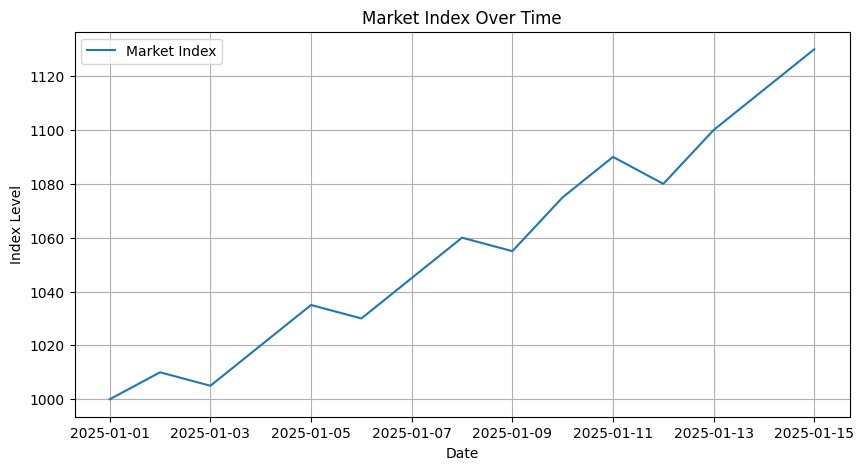

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(prices.index, prices["Market_Index"], label="Market Index")

plt.title("Market Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
returns = prices.pct_change()

print(returns.head())

             Stock_A   Stock_B   Stock_C  Market_Index
Date                                                  
2025-01-01       NaN       NaN       NaN           NaN
2025-01-02  0.020000  0.012500 -0.013333      0.010000
2025-01-03 -0.009804  0.024691  0.020270     -0.004950
2025-01-04  0.039604 -0.012048 -0.013245      0.014925
2025-01-05  0.028571  0.024390  0.026846      0.014706


In [28]:
average_returns = returns.mean() * 100

print("Average daily returns (%):")
print(average_returns)

Average daily returns (%):
Stock_A         1.797225
Stock_B         1.399885
Stock_C         0.954466
Market_Index    0.881388
dtype: float64


In [29]:
volatility = returns.std() * 100

print("Daily volatility (%):")
print(volatility)

Daily volatility (%):
Stock_A         1.993756
Stock_B         1.745401
Stock_C         1.749338
Market_Index    0.995289
dtype: float64


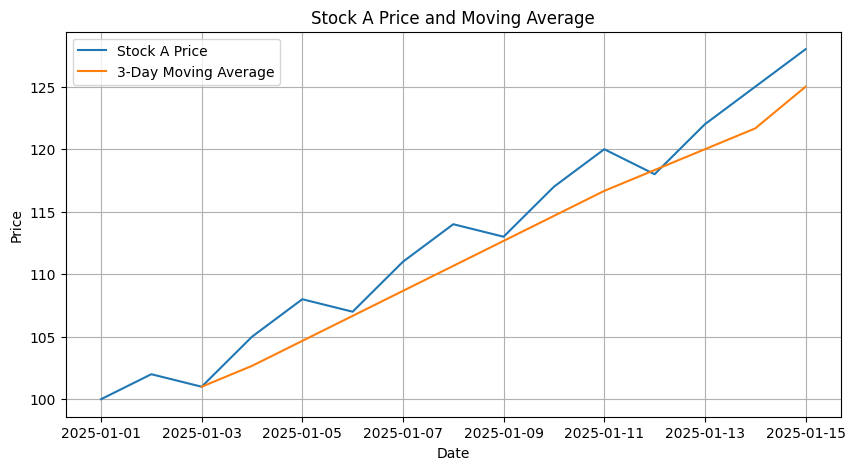

In [30]:
prices["Stock_A_MA_3"] = prices["Stock_A"].rolling(window=3).mean()

plt.figure(figsize=(10, 5))

plt.plot(prices.index, prices["Stock_A"], label="Stock A Price")
plt.plot(prices.index, prices["Stock_A_MA_3"], label="3-Day Moving Average")

plt.title("Stock A Price and Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
correlation = returns.corr()

print("Return correlation matrix:")
print(correlation)

Return correlation matrix:
               Stock_A   Stock_B   Stock_C  Market_Index
Stock_A       1.000000 -0.538486 -0.492131      0.980079
Stock_B      -0.538486  1.000000  0.919677     -0.443096
Stock_C      -0.492131  0.919677  1.000000     -0.404742
Market_Index  0.980079 -0.443096 -0.404742      1.000000


In [32]:
market_variance = returns["Market_Index"].var()

beta_A = (
    returns["Stock_A"].cov(returns["Market_Index"])
    / market_variance
)

beta_B = (
    returns["Stock_B"].cov(returns["Market_Index"])
    / market_variance
)

beta_C = (
    returns["Stock_C"].cov(returns["Market_Index"])
    / market_variance
)

print("Stock A beta:", beta_A)
print("Stock B beta:", beta_B)
print("Stock C beta:", beta_C)

Stock A beta: 1.9632869646649094
Stock B beta: -0.7770398546663777
Stock C beta: -0.7113812159342523


In [33]:
sharpe_A = returns["Stock_A"].mean() / returns["Stock_A"].std()
sharpe_B = returns["Stock_B"].mean() / returns["Stock_B"].std()
sharpe_C = returns["Stock_C"].mean() / returns["Stock_C"].std()
sharpe_Market = (
    returns["Market_Index"].mean()
    / returns["Market_Index"].std()
)

print("Stock A Sharpe ratio:", sharpe_A)
print("Stock B Sharpe ratio:", sharpe_B)
print("Stock C Sharpe ratio:", sharpe_C)
print("Market Sharpe ratio:", sharpe_Market)

Stock A Sharpe ratio: 0.9014271055768133
Stock B Sharpe ratio: 0.8020421145824452
Stock C Sharpe ratio: 0.5456154279144859
Market Sharpe ratio: 0.8855600491602209


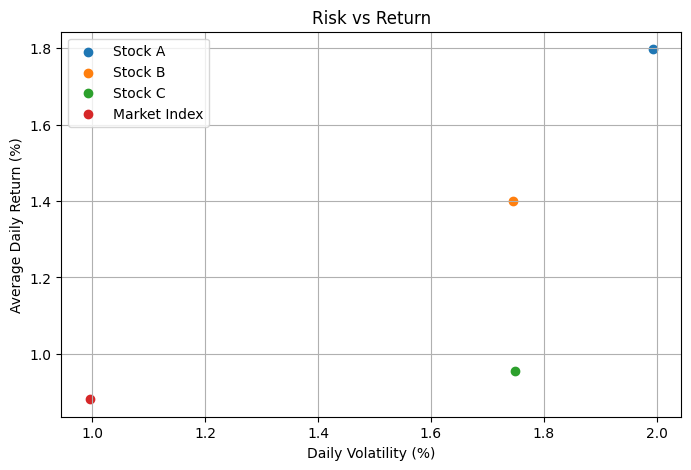

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(volatility["Stock_A"], average_returns["Stock_A"], label="Stock A")
plt.scatter(volatility["Stock_B"], average_returns["Stock_B"], label="Stock B")
plt.scatter(volatility["Stock_C"], average_returns["Stock_C"], label="Stock C")
plt.scatter(volatility["Market_Index"], average_returns["Market_Index"], label="Market Index")

plt.title("Risk vs Return")
plt.xlabel("Daily Volatility (%)")
plt.ylabel("Average Daily Return (%)")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
portfolio_weights = np.array([0.50, 0.30, 0.20])

estimated_returns = np.array([
    returns["Stock_A"].mean(),
    returns["Stock_B"].mean(),
    returns["Stock_C"].mean()
])

portfolio_expected_return = np.dot(
    portfolio_weights,
    estimated_returns
)

print("Illustrative portfolio expected daily return (%):")
print(portfolio_expected_return * 100)

Illustrative portfolio expected daily return (%):
1.509471258541079


In [36]:
summary = pd.DataFrame({
    "Average_Daily_Return_Pct": average_returns,
    "Daily_Volatility_Pct": volatility,
    "Daily_Sharpe_Ratio": [
        sharpe_A,
        sharpe_B,
        sharpe_C,
        sharpe_Market
    ],
    "Beta_vs_Market": [
        beta_A,
        beta_B,
        beta_C,
        1.0
    ]
})

print(summary.round(3))

              Average_Daily_Return_Pct  Daily_Volatility_Pct  \
Stock_A                          1.797                 1.994   
Stock_B                          1.400                 1.745   
Stock_C                          0.954                 1.749   
Market_Index                     0.881                 0.995   

              Daily_Sharpe_Ratio  Beta_vs_Market  
Stock_A                    0.901           1.963  
Stock_B                    0.802          -0.777  
Stock_C                    0.546          -0.711  
Market_Index               0.886           1.000  


Project objective

This project compares the historical return and risk characteristics of three synthetic stocks and a synthetic market index using Python, pandas, NumPy and Matplotlib.

Methods

I calculated daily simple returns, average daily returns, daily volatility, a moving average, return correlations, beta and daily Sharpe ratios. I also created price and risk–return charts and calculated an illustrative portfolio expected return using np.dot().

Limitations

The dataset contains only 15 synthetic observations on consecutive calendar dates, including weekends. The results are for educational purposes and do not represent real market performance. The Sharpe ratio assumes a zero daily risk-free return. Statistics calculated from this small sample should not be used to predict future investment returns.

Conclusion

Returns, volatility, correlation, beta and Sharpe ratios describe different aspects of an asset’s behaviour. Comparing these measures together provides a broader picture than looking at returns alone.